##### Copyright 2020 Google LLC.

## SimCLR: A Simple Framework for Contrastive Learning of Visual Representations

This notebook demonstrates how to load pretrained SimCLRv2 models and run inference.

**Updated:** Original checkpoints at `gs://simclr-checkpoints` and TFHub URLs are no longer publicly accessible.
This notebook has been rewritten in **PyTorch** using official SimCLRv2 weights hosted on HuggingFace by [lightly-ai](https://huggingface.co/collections/lightly-ai/simclrv2-pytorch-weights-675c22e6003cee9ea31bd1f8).

### Contents
* **Part I** – Install dependencies & load the SimCLRv2 model, count parameters
* **Part II** – Load the tf_flowers dataset and run inference


## Part I – Install dependencies & load SimCLRv2

In [ ]:
# Install required packages
!pip install torch torchvision huggingface_hub tensorflow_datasets matplotlib numpy --quiet


In [ ]:
import re
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from huggingface_hub import hf_hub_download
import matplotlib
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [ ]:
# ─────────────────────────────────────────────────────────────
# Load SimCLRv2 ResNet-50 (1x, no SK) weights from HuggingFace
# Official PyTorch-converted weights by lightly-ai
# Replaces the broken gs://simclr-checkpoints and tfhub.dev paths
# ─────────────────────────────────────────────────────────────

REPO_ID = 'lightly-ai/simclrv2-imagenet1k-r50_1x_sk0'
ckpt_path = hf_hub_download(repo_id=REPO_ID, filename='r50_1x_sk0.pth')

# Build ResNet-50 backbone (remove classification head for feature extraction)
backbone = models.resnet50(weights=None)
backbone.fc = nn.Identity()
backbone = backbone.to(device)

# Load SimCLRv2 pretrained weights
state_dict = torch.load(ckpt_path, map_location=device)
backbone.load_state_dict(state_dict, strict=False)
backbone.eval()

print('Model loaded successfully from HuggingFace!')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


r50_1x_sk0.pth:   0%|          | 0.00/137M [00:00<?, ?B/s]

Model loaded successfully from HuggingFace!


In [ ]:
# Count parameters (equivalent to the original count_params function)
def count_params(model, verbose=False):
    total = 0
    for name, param in model.named_parameters():
        if verbose:
            print(name, param.shape)
        total += param.numel()
    print(f'Total number of parameters: {total/1e6:.2f}M')
    return total

count_params(backbone, verbose=False)


Total number of parameters: 23.51M


23508032

## Part II – Load tf_flowers dataset and run inference

In [ ]:
import urllib.request
import json

try:
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json',
        'imagenet_labels.json'
    )
    with open('imagenet_labels.json') as f:
        labels_list = json.load(f)
    imagenet_int_to_str = {i: labels_list[i] for i in range(len(labels_list))}
    print(f'Loaded {len(imagenet_int_to_str)} ImageNet labels.')
except Exception as e:
    print(f'Download failed ({e}), using numeric fallback.')
    imagenet_int_to_str = {i: f'class_{i}' for i in range(1000)}

tf_flowers_labels = ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
print('Label mappings loaded.')


Loaded 1000 ImageNet labels.
Label mappings loaded.


In [ ]:
# ImageNet normalisation used by SimCLRv2
preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load tf_flowers via tensorflow_datasets, convert to PyTorch tensors
batch_size = 5
tfds_dataset = tfds.load('tf_flowers', split='train', as_supervised=False)

images_raw, labels_list = [], []
for sample in tfds_dataset.take(batch_size):
    img = sample['image'].numpy()           # H x W x 3  uint8
    images_raw.append(img)
    labels_list.append(int(sample['label'].numpy()))

# Preprocess and stack into a batch tensor
batch = torch.stack([preprocess(img) for img in images_raw]).to(device)
labels = np.array(labels_list)
print(f'Batch shape: {batch.shape},  Labels: {labels}')


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.RCVQ6H_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Batch shape: torch.Size([5, 3, 224, 224]),  Labels: [2 3 3 4 3]


In [ ]:
# ─────────────────────────────────────────────────────────────
# Add a linear classification head on top of the backbone
# for ImageNet 1000-class inference (matches original notebook)
# ─────────────────────────────────────────────────────────────

class SimCLRWithHead(nn.Module):
    def __init__(self, backbone, num_classes=1000):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(2048, num_classes)

    def forward(self, x):
        features = self.backbone(x)   # [B, 2048]
        return self.classifier(features)

model_with_head = SimCLRWithHead(backbone).to(device)
model_with_head.eval()

with torch.no_grad():
    logits = model_with_head(batch).cpu().numpy()  # [5, 1000]

pred = logits.argmax(-1)
print('Predicted ImageNet class indices:', pred)


Predicted ImageNet class indices: [ 96 790 790 790 790]


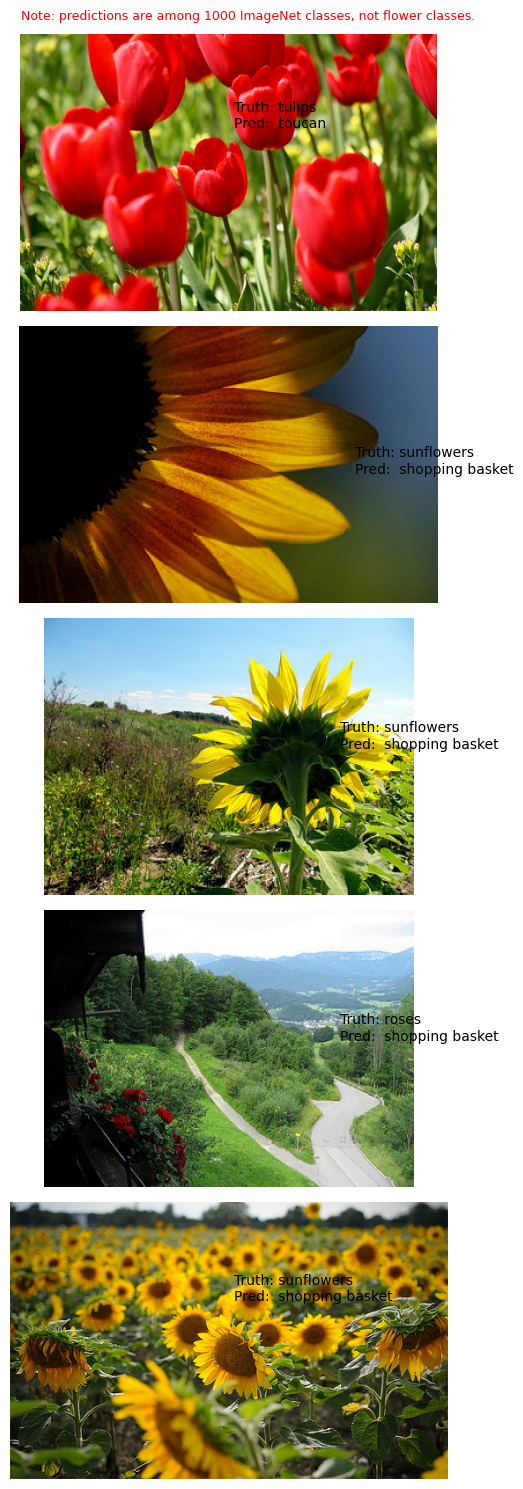

In [ ]:
# Plot images with true flower labels and predicted ImageNet labels
fig, axes = plt.subplots(5, 1, figsize=(15, 15))
for i in range(5):
    axes[i].imshow(images_raw[i])
    true_text = tf_flowers_labels[labels[i]]
    pred_text = imagenet_int_to_str[pred[i]]
    if i == 0:
        axes[i].text(0, 0,
            'Note: predictions are among 1000 ImageNet classes, not flower classes.\n',
            c='r', fontsize=9)
    axes[i].axis('off')
    axes[i].text(256, 112, f'Truth: {true_text}\nPred:  {pred_text}', fontsize=10)
plt.tight_layout()
plt.show()
